# Retrieval Augmented Generation

## Initial Setup

In [1]:
# !brew install wget
# !brew install poppler

In [2]:
## Set HuggingFace token
# You need to set the HuggingFace token and save it inside the .env file. Save it as HF_TOKEN=your_token_here.

In [3]:
# !echo "TOKENIZERS_PARALLELISM = false" >> .env
# !echo "OCR_AGENT=unstructured.partition.utils.ocr_models.tesseract_ocr.OCRAgentTesseract" >> .env

In [4]:
import os, json, re, getpass, warnings
import numpy as np
from dotenv import load_dotenv
from uuid import uuid4
from IPython.display import display, Markdown

In [8]:
warnings.filterwarnings('ignore')
load_dotenv(override=True)

True

In [9]:
#Check for Groq API Key
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("GROQ API Key: ")

In [10]:
#Set Hugging Face token (as we will be using some of Hugging Face's functionalities
from huggingface_hub.hf_api import HfFolder
HfFolder.save_token(os.environ["HF_TOKEN"])

In [11]:
np.__version__

'2.2.6'

## Part 1: Indexing

In [12]:
# Question
question = "What is Jio Institute all about?"

### Concept: Tokenization

**tiktoken** is a fast BPE tokenizer for use with OpenAI's models. It takes a 1) text string and 2) encoding to convert string to tokens.

**About encodings:** Encodings specify how text is converted into tokens. Different models use different encodings. 

`tiktoken` supports following encodings used by OpenAI models:

| Encoding name | OpenAI models |
|---|---|
| `o200k_base` | gpt-4o, gpt-4o-mini |
| `cl100k_base` | gpt-4-turbo, gpt-4, gpt-3.5-turbo, text-embedding-ada-002, text-embedding-3-small, text-embedding-3-large |
| `p50k_base` | Codex models, text-davinci-002, text-davinci-003 |
| `r50k_base` (or `gpt2`) | GPT-3 models like davinci |

**Note:** You can check out how a string is tokenized using the third-party [Tiktokenizer](https://tiktokenizer.vercel.app/) app. 

In [13]:
#Import library
import tiktoken

In [14]:
#Load an encoding - load encoding by name 
encoding = tiktoken.get_encoding("cl100k_base")

In [15]:
#Load an encoding - load encoding for a model 
encoding = tiktoken.encoding_for_model("gpt-4o-mini")

In [16]:
#Turn text into tokens
tokens = encoding.encode(question)
tokens

[4827, 382, 643, 726, 14544, 722, 1078, 30]

In [17]:
len(tokens)

8

In [18]:
#Count tokens
def num_tokens_from_string(string: str, encoding_name: str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    tokens = encoding.encode(string)
    num_tokens = len(tokens)
    return num_tokens

In [19]:
num_tokens_from_string(question, "cl100k_base")

8

In [20]:
#Decode list of token integers to string
encoding.decode(tokens)

'What is Jio Institute all about?'

#### What about non-OpenAI models?

 Use AutoTokenizer class from Hugging Face `transformers` library.

**Important points**:
- Make sure you have have created token and logged into Hugging Face Hub.
- Please ensure the model name is correct; if it's a gated model, you might need get access from the model page on Hugging Face Hub.
    - Access to model meta-llama/Llama-3.1-8B is restricted by default, in our example. Visit https://huggingface.co/meta-llama/Llama-3.1-8B to ask for access.

In [21]:
from transformers import AutoTokenizer

In [22]:
#Model name should be as per Hugging Face - exact name can differ from the model name in Ollama/Groq, for example
model_name = "meta-llama/Llama-3.1-8B"

In [23]:
# Load the tokenizer for the specified Llama 3.2 model.
# `trust_remote_code=True` is often necessary for custom model architectures.
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

In [24]:
# Tokenize the input text.
# `add_special_tokens=False` can be used if you only want to count content tokens
# without BOS/EOS tokens, but typically for LLM usage, special tokens are included.
tokens = tokenizer.encode(question, add_special_tokens=True)
tokens

[128000, 3923, 374, 622, 822, 10181, 682, 922, 30]

In [25]:
len(tokens)

9

**Note**: Typically, we do not need to tokenize the text beforehand when using any embedding model. Most other embedding models from libraries like LangChain or directly from model providers handle the tokenization internally as part of its process to generate the embeddings!

### Concept: Embedding

Conceptual Reference - [Embedding models](https://python.langchain.com/docs/concepts/embedding_models/)

Check out this MTEB leaderboard for benchmarking embedding models: [MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard) 

You can choose different embedding models based on 
1) Embedding dimension
2) Max tokens supported
3) Performance/accuracy (on specific tasks)
4) Multilinguality/Language Support
5) Model Size and Inference Speed/Efficiency
6) Licensing and Usage Restrictions
7) Cost (for API-based, like OpenAI)

In [33]:
!ollama pull nomic-embed-text

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest 
pulling 970aa74c0a90:   0% ▕                  ▏ 284 KB/274 MB                  pulling manifest 
pulling 970aa74c0a90:   1% ▕                  ▏ 3.6 MB/274 MB                  pulling manifest 
pulling 970aa74c0a90:   2% ▕                  ▏ 5.3 MB/274 MB                  pulling manifest 
pulling 970aa74c0a

In [34]:
from langchain_ollama import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="nomic-embed-text")

**Benefit of LangChain**: It provides a universal interface for working with embedding models. The two central methods are:

- `embed_documents`: for embedding multiple texts (documents)
- `embed_query`: for embedding a single text (query)

In [35]:
embeddings = embeddings_model.embed_documents(
    [
        "Hi there!",
        "We are studying Agentic AI today.",
        "How's the weather?",
        "Hello there!"
    ]
)

In [36]:
#Embedding is a list of lists - so we convert to a NumPy array to see shape
np.array(embeddings).shape

(4, 768)

In [37]:
query_embedding = embeddings_model.embed_query(question)

In [38]:
#Embedding is now a list - still we convert to a NumPy array to see shape
np.array(query_embedding).shape

(768,)

#### Calculating Similarity

There are 3 common metrics used to measure similarity:

- Cosine similarity (opposite of cosine distance)
- Euclidean distance
- Dot product

Choice of similarity metric depends on the model, for example, [OpenAI suggests to use cosine similarity](https://platform.openai.com/docs/guides/embeddings/which-distance-function-should-i-use) as the primary metric. However, all the 3 metrics are similar in some aspects, so choice of metric is not a major consideration in general (see article from Google [here](https://developers.google.com/machine-learning/clustering/dnn-clustering/supervised-similarity) that demonstrates proportionality of similarity measures).

In [39]:
#Sample code for cosine similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

In [40]:
question

'What is Jio Institute all about?'

In [41]:
query_1_embedding = embeddings_model.embed_query("Jio Institute is a world-class, research-focused higher education institution located in Navi Mumbai, India.")
query_2_embedding = embeddings_model.embed_query("The AI&DS program fosters innovation, research, and leadership in AI field for the students.")

In [42]:
similarity = cosine_similarity(query_1_embedding, query_2_embedding)
print("Cosine Similarity:", similarity)

Cosine Similarity: 0.5276940210437624


It has a high cosine similarity, as expected.

**Question**: 
- What is the min and max of cosine similarity metric?
- What about dot product (inner product)?
- What about euclidean distance?

### Loading Documents

Reference - [Document Loaders](https://python.langchain.com/docs/integrations/document_loaders/)

**What is Beautiful Soup?** It is a library used to scrape information from web pages. It uses an HTML or XML parser under the hood!

In [43]:
import bs4 #import Beautiful Soup
from langchain_community.document_loaders import WebBaseLoader

USER_AGENT environment variable not set, consider setting it to identify your requests.


WebBaseLoader is a tool in LangChain that fetches content from web URLs and converts it into standard document objects

In [53]:
# Only keep the main content from the full HTML
bs4_strainer = bs4.SoupStrainer(class_=("neutral-10-bg programme-scrolling section-common-space layout layout--onecol", 
                                        "container programme-scrolling section-common-space bd-container-space layout layout--onecol",
                                       "main_container academic_section_wrap trigger3 bg_img layout layout--onecol"))
loader = WebBaseLoader(
    web_paths=("https://www.jioinstitute.edu.in/academics/artificial-intelligence-data-science", 
               "https://www.jioinstitute.edu.in"),
    bs_kwargs={"parse_only": bs4_strainer},
)
docs = loader.load()

assert len(docs) == 2

print(f"Total characters: {len(docs[0].page_content)}")
print(docs[0].page_content) # Print a snippet to verify

Total characters: 30513









Course Curriculum







No Description
 Foundation Courses

Mathematical Foundations (Probability, Statistics, Linear Algebra)




Mathematical Foundations (Probability, Statistics, Linear Algebra)

x


This course covers essential mathematical concepts that form the backbone of AI and machine learning. Students will explore probability theory, statistical inference, and key linear algebra techniques used in data representation and model computations. Emphasis is placed on eigenvalues, matrix factorization, and vector spaces, crucial for optimization and deep learning. The course includes practical applications in AI and real-world problem-solving. By the end, learners will develop a strong mathematical intuition for AI algorithms. Hands-on exercises reinforce theoretical concepts through Python-based implementations.






Python Programming




Python Programming

x


This course provides a foundational and practical introduction to Python for AI and

In [54]:
print(f"Total characters: {len(docs[0].page_content)}")
print(docs[0].page_content) # Print a snippet to verify

Total characters: 30513









Course Curriculum







No Description
 Foundation Courses

Mathematical Foundations (Probability, Statistics, Linear Algebra)




Mathematical Foundations (Probability, Statistics, Linear Algebra)

x


This course covers essential mathematical concepts that form the backbone of AI and machine learning. Students will explore probability theory, statistical inference, and key linear algebra techniques used in data representation and model computations. Emphasis is placed on eigenvalues, matrix factorization, and vector spaces, crucial for optimization and deep learning. The course includes practical applications in AI and real-world problem-solving. By the end, learners will develop a strong mathematical intuition for AI algorithms. Hands-on exercises reinforce theoretical concepts through Python-based implementations.






Python Programming




Python Programming

x


This course provides a foundational and practical introduction to Python for AI and

In [55]:
# --- Post-processing to clean up excessive newlines and whitespace ---
for i, doc in enumerate(docs):
    if doc.page_content:
        # 1. Replace multiple newlines with a single newline
        cleaned_content = re.sub(r'\n\s*\n', '\n\n', doc.page_content)
        # 2. Replace multiple spaces with a single space
        cleaned_content = re.sub(r' {2,}', ' ', cleaned_content)
        # 3. Strip leading/trailing whitespace from each line
        cleaned_content = '\n'.join([line.strip() for line in cleaned_content.split('\n')])
        # 4. Remove leading/trailing whitespace from the whole string
        cleaned_content = cleaned_content.strip()
    
        docs[i].page_content = cleaned_content
# --- End of post-processing ---

In [56]:
print(f"Total characters: {len(docs[1].page_content)}")
print("\n--- Cleaned Content Snippet ---")
print(docs[1].page_content) # Print a snippet to verify

Total characters: 1445

--- Cleaned Content Snippet ---
Academics
Our programmes are carefully designed to achieve academic excellence, business relevance and social significance.World-class faculty and strong emphasis on research are central to our programmes. With focus on holistic development through interdisciplinary learning and global exposure, Jio Institute will enable students to grow and make an impact in society.

PGP in Artificial Intelligence & Data Science
From building and deploying industry-scale AI models to learning theoretical as well as practical foundations of ‘AI Thinking’, the Post Graduate Programme in AI & Data Science will enable learners to transform enterprises and societies from merely ‘Data-rich’ to ‘AI-first’.
Know more
Know more

PGP in Management
This future-ready postgraduate programme in Management is designed to build a strong foundation in management, analytics, and AI while offering deep specialisation in Marketing or Finance. The curriculum integra

In [57]:
print(f"Total characters: {len(docs[1].page_content)}")
print("\n--- Cleaned Content Snippet ---")
print(docs[1].page_content[:1000]) # Print a snippet to verify

Total characters: 1445

--- Cleaned Content Snippet ---
Academics
Our programmes are carefully designed to achieve academic excellence, business relevance and social significance.World-class faculty and strong emphasis on research are central to our programmes. With focus on holistic development through interdisciplinary learning and global exposure, Jio Institute will enable students to grow and make an impact in society.

PGP in Artificial Intelligence & Data Science
From building and deploying industry-scale AI models to learning theoretical as well as practical foundations of ‘AI Thinking’, the Post Graduate Programme in AI & Data Science will enable learners to transform enterprises and societies from merely ‘Data-rich’ to ‘AI-first’.
Know more
Know more

PGP in Management
This future-ready postgraduate programme in Management is designed to build a strong foundation in management, analytics, and AI while offering deep specialisation in Marketing or Finance. The curriculum integra

#### Other Useful Loaders - UnstructuredPDFLoader (Example Implementation)

[Portable Document Format (PDF)](https://en.wikipedia.org/wiki/PDF), standardized as ISO 32000, is a file format developed by Adobe in 1992 to present documents, including text formatting and images, in a manner independent of application software, hardware, and operating systems.

LangChain integrates with a host of PDF parsers. Some are simple and relatively low-level; others will support OCR and image-processing, or perform advanced document layout analysis. The right choice will depend on your use-case and through experimentation.

Here we will see how to load PDF documents into the LangChain `Document` format

We download a research paper to experiment with.

In [58]:
!wget -O 'layoutparser_paper.pdf' 'http://arxiv.org/pdf/2103.15348.pdf'

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


--2026-09-08 17:56:00--  http://arxiv.org/pdf/2103.15348.pdf
Resolving arxiv.org (arxiv.org)... 151.101.3.42, 151.101.67.42, 151.101.195.42, ...
Connecting to arxiv.org (arxiv.org)|151.101.3.42|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://arxiv.org/pdf/2103.15348.pdf [following]
--2026-09-08 17:56:01--  https://arxiv.org/pdf/2103.15348.pdf
Connecting to arxiv.org (arxiv.org)|151.101.3.42|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /pdf/2103.15348 [following]
--2026-09-08 17:56:01--  https://arxiv.org/pdf/2103.15348
Reusing existing connection to arxiv.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 4686220 (4.5M) [application/pdf]
Saving to: ‘layoutparser_paper.pdf’

layoutparser_paper. 100%[===================>]   4.47M  1.68MB/s    in 2.7s    

2026-09-08 17:56:05 (1.68 MB/s) - ‘layoutparser_paper.pdf’ saved [4686220/4686220]



**UnstructuredPDFLoader**

[Unstructured.io](https://unstructured-io.github.io/unstructured/) supports a common interface for working with unstructured or semi-structured file formats, such as Markdown or PDF. LangChain's [`UnstructuredPDFLoader`](https://api.python.langchain.com/en/latest/document_loaders/langchain_community.document_loaders.pdf.UnstructuredPDFLoader.html) integrates with Unstructured to parse PDF documents into LangChain [`Document`](https://api.python.langchain.com/en/latest/documents/langchain_core.documents.base.Document.html) objects.

In [59]:
from langchain_community.document_loaders import UnstructuredPDFLoader

In [60]:
#This takes 3-4 minutes to run
loader = UnstructuredPDFLoader('./layoutparser_paper.pdf',
                               strategy='hi_res',
                               extract_images_in_pdf=True,
                               infer_table_structure=True,
                               chunking_strategy="by_title", # section-based chunking
                               max_characters=4000, # max size of chunks
                               new_after_n_chars=3800, # preferred size of chunks
                               combine_text_under_n_chars=2000, # smaller chunks < 2000 chars will be combined into a larger chunk
                               mode='elements')
data = loader.load()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if

In [61]:
len(data)

16

In [62]:
[doc.metadata['category'] for doc in data]

['CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement']

In [63]:
data[0]

Document(metadata={'source': './layoutparser_paper.pdf', 'filetype': 'application/pdf', 'languages': ['eng'], 'last_modified': '2023-01-23T14:45:33', 'page_number': 1, 'orig_elements': 'eJy9V+9v3DYS/Vd4+ykpVqp+r+QvtRMDl7TuXZC410PdwKDE0S4TSRRIap1Nrv/7PVK7ziZxC9SA/ckmxeHMvPdmhnv1aUEd9TTYaykWJ2yRZyuqojgL6qLNg4yvooAXSRrUZZlWKxKpaOPFki16slxwy2HzadEopYUcuCXj1x3fqcleb0iuNxY7SRJFsNlv30hhN9iNV353VHKwzu7qKivCfMnyPAuzt0u2X8ZRmoSxW1erMPp2PR/HemF2xlLvsnglP1D3ZuQNLf7AB0GWGivVcN103JjrUasax6IwL7IixoFWdmR3I3nbVz8vfLDDeuJrn9HVgob14q3fNfa6V0K2kjxeSQRwojhI0ss4O8nykzR11iMsr4epr0m7TF0Qlj44LBZXjQmf/+ctS2L24zQwXOABPbh/QVzACBZfU5OmoioyioOWyirI6qQKyrrNglxQS1RnKc/yB6Mmj2bsqzyMHPb7dZ6n87os71zP5/+SnMfEPoF4wjhPs3KbMK7/K7fH0P8yNMBprbT8SOLSmdzBQlvyKE7rLFjFsQiyIsoDzkkEdVvHoCMVq4Q/XIGkuSuJNC7D0lfIvM6iakY9Tla5w/2bjdninkWSrdLykYm68Ei84tqQPmFn7JfBX8YulereS8tapdk50cguiOtBDmv2jBt8P1fN5MhiL3tczs4G3u2MNMcsX0rb0V3MJu2qzAlUplFRBFnb1gEXIg7KiMq2xNe4fThm08IXTLaK5962X0OqYeKJTLM4XN2xMVvck9kqL4pHZvY3eidxN3uzoeEf7En2dMleT6rBiv22wYffpy

In [64]:
print(data[1].page_content)

1 Introduction

Deep Learning(DL)-based approaches are the state-of-the-art for a wide range of document image analysis (DIA) tasks including document image classification

2 Z. Shen et al.

table detection [37], layout de and scene text detection [4]. A generalized learning-based framework dramatically reduces the need for the manual specification of complicated rules, which is the status quo with traditional methods. DL has the potential to transform DIA pipelines and benefit a broad spectrum of large-scale document digitization projects.

However, there are several practical difficulties for taking advantages of re- cent advances in DL-based methods: 1) DL models are notoriously convoluted for reuse and extension. Existing models are developed using distinct frame- works like TensorFlow [I] or PyTorch be obfuscated by implementation details and the high-level parameters can . It can be a time-consuming and frustrating experience to debug, reproduce, and adapt existing models for DIA

In [65]:
! ls -l ./figures

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


total 648
-rw-r--r--@ 1 anantagarwal  staff  84771 Sep  8 17:56 figure-10-4.jpg
-rw-r--r--@ 1 anantagarwal  staff  41639 Sep  8 17:56 figure-11-5.jpg
-rw-r--r--@ 1 anantagarwal  staff  62560 Sep  8 17:56 figure-13-6.jpg
-rw-r--r--@ 1 anantagarwal  staff  36497 Sep  8 17:56 figure-4-1.jpg
-rw-r--r--@ 1 anantagarwal  staff  29862 Sep  8 17:56 figure-6-2.jpg
-rw-r--r--@ 1 anantagarwal  staff  64442 Sep  8 17:56 figure-9-3.jpg


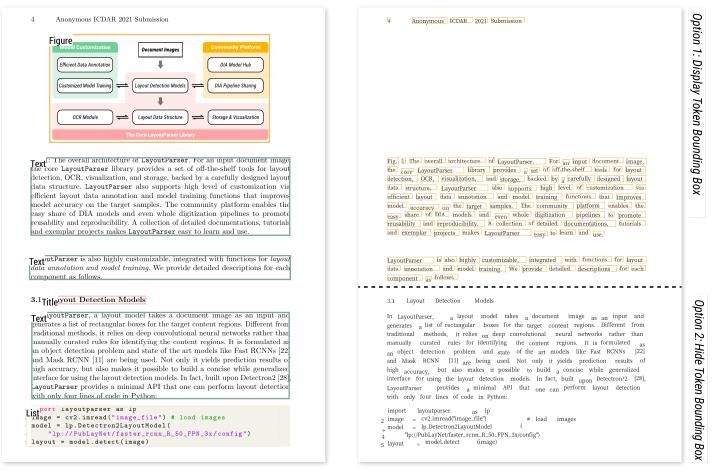

In [66]:
from IPython.display import Image

Image('./figures/figure-9-3.jpg')

### Splitting Documents

**Overview**

* **Goal of Chunking:** Optimize data for effective future retrieval

* **Character Splitting**: Divides text into fixed N-character chunks, ignoring content or structure. However, it's very rigid; disregards text structure, making it generally not recommended.

* **Recursive Character Text Splitting**: Addresses character splitting's rigidity by using a series of specified separators to split documents, considering their structure. This is a versatile "swiss army knife" approach, often the first choice for quick applications. Some default Separators (e.g., in LangChain):

    * `"\n\n"`: Double newlines (paragraph breaks).
    * `"\n"`: Single newlines.
    * `" "` : Spaces.
    * `""` : Individual characters.

* **Hyperparameters (should be tuned!):**
  * **Chunk Size:** The desired number of characters per chunk (e.g., 50, 100). (**not tokens!**)
  * **Chunk Overlap:** The amount sequential chunks overlap to avoid context breaks, creating duplicate data (e.g., if chunk 1 is chars 1-100, chunk 2 might be 81-180 with 20 overlap).


**More References**

Check out this nice visualization to understand Character Splitting and Recursive Character Text Splitting - https://chunkviz.up.railway.app/

Reference (LangChain) - [Text Splitters](https://python.langchain.com/docs/concepts/text_splitters/)

Overview of popular methods: 

| Splitter Type              | Description                                                                                                                              |
| :------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------- |
| `RecursiveCharacterTextSplitter` | Recursively splits text into larger chunks based on several defined characters. Tries to keep related pieces of text next to each other. LangChain's recommended way to start splitting text |
| `CharacterTextSplitter`    | Splits text based on a user defined character. One of the simpler text splitters                                                         |
| `tiktoken`                 | Splits text based on tokens using trained LLM tokenizers like GPT-4                                                                      |
| `spaCy`                    | Splits text using the tokenizer from the popular NLP library - `spaCy`                                                                   |
| `SentenceTransformers`     | Splits text based on tokens using trained open LLM tokenizers available from the popular `sentence-transformers` library                 |
| `unstructured.io`          | The unstructured library allows various splitting and chunking strategies including splitting text based on key sections and titles      |

#### Recursive Character Text Splitter

In [67]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # chunk size (characters) - hyperparameter that can be tuned
    chunk_overlap=200,  # chunk overlap (characters) - hyperparameter that can be tuned
    add_start_index=True,  # track index in original document
)
all_splits = text_splitter.split_documents(docs)

print(f"Split blog post into {len(all_splits)} sub-documents.")

Split blog post into 49 sub-documents.


In [68]:
for i in range(len(all_splits)):
    print(f"\n--- Split{i} ---\n")
    print(all_splits[i].page_content)


--- Split0 ---

Course Curriculum

No Description
Foundation Courses

Mathematical Foundations (Probability, Statistics, Linear Algebra)

Mathematical Foundations (Probability, Statistics, Linear Algebra)

x

This course covers essential mathematical concepts that form the backbone of AI and machine learning. Students will explore probability theory, statistical inference, and key linear algebra techniques used in data representation and model computations. Emphasis is placed on eigenvalues, matrix factorization, and vector spaces, crucial for optimization and deep learning. The course includes practical applications in AI and real-world problem-solving. By the end, learners will develop a strong mathematical intuition for AI algorithms. Hands-on exercises reinforce theoretical concepts through Python-based implementations.

Python Programming

Python Programming

x

--- Split1 ---

Python Programming

Python Programming

x

This course provides a foundational and practical introducti

#### Semantic Text Splitter (custom innovation)

Innovated by Greg Kamradt [here](https://github.com/FullStackRetrieval-com/RetrievalTutorials/blob/main/tutorials/LevelsOfTextSplitting/5_Levels_Of_Text_Splitting.ipynb), and adapted by both LangChain and Llamaindex!

Semantic chunking splits text into coherent segments based on semantic similarity. It works by initially splitting text into sentences, then grouping them into groups of 3, and finally merging those groups whose embeddings are semantically close.

In [69]:
from langchain_experimental.text_splitter import SemanticChunker

In [70]:
#Create text splitter
text_splitter_semantic = SemanticChunker(embeddings_model)

In [71]:
len(docs[1].page_content)

1445

In [72]:
#Reduce content of second doc for faster runtimes
from langchain_core.documents import Document
docs_truncated = docs.copy()
docs_truncated[1] = Document(page_content= docs[1].page_content[:5000], metadata=docs[1].metadata)

In [73]:
#Split the documents into chunks (only pick second one)
all_splits_semantic = text_splitter_semantic.split_documents(docs_truncated)
print(f"Split input into {len(all_splits_semantic)} sub-documents.")

Split input into 12 sub-documents.


In [74]:
for i in range(len(all_splits_semantic)):
    print(f"\n--- Split{i} ---\n")
    print(all_splits_semantic[i].page_content)


--- Split0 ---

Course Curriculum

No Description
Foundation Courses

Mathematical Foundations (Probability, Statistics, Linear Algebra)

Mathematical Foundations (Probability, Statistics, Linear Algebra)

x

This course covers essential mathematical concepts that form the backbone of AI and machine learning. Students will explore probability theory, statistical inference, and key linear algebra techniques used in data representation and model computations. Emphasis is placed on eigenvalues, matrix factorization, and vector spaces, crucial for optimization and deep learning. The course includes practical applications in AI and real-world problem-solving. By the end, learners will develop a strong mathematical intuition for AI algorithms. Hands-on exercises reinforce theoretical concepts through Python-based implementations. Python Programming

Python Programming

x

This course provides a foundational and practical introduction to Python for AI and data science applications. Students 

In [75]:
#Remember that the entire document has been split into smaller documents (which we are calling chunks!)
type(all_splits_semantic[0])

langchain_core.documents.base.Document

**This is much better, as we inspect on the homepage!** Note, that this method requires the use of a embedding model and is relatively much slower!

### Storing Documents in Vector Store

Conceptual Reference - [Vector stores](https://python.langchain.com/docs/concepts/vectorstores/)

#### FAISS

**Facebook AI Similarity Search (FAISS)** is one of the popular implementations of *efficient similarity search*. It allows us to build an index and search, but it *speeds up search times to high performance levels*.

FAISS (Facebook AI Similarity Search) takes a matrix of vectors and builds a data structure that answers "give me the k nearest neighbors of this query vector" very fast.

In [76]:
#Import libraries
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

In [77]:
#To get the dimension of the embedding generated by the model
print(question)
query_embedding = embeddings_model.embed_query(question)
len(query_embedding)

What is Jio Institute all about?


768

In [78]:
#Initialize the index (using the basic IndexFlatL2 - there are IndexIVFFlat and IndexIVFPQ also available that're faster. Note the tradeoff between accuracy and speed)
index = faiss.IndexFlatL2(len(query_embedding))

In [79]:
#Create a vector store
vector_store_faiss = FAISS(
    embedding_function=embeddings_model,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

In [80]:
len(all_splits_semantic)

12

In [81]:
all_splits_semantic

[Document(metadata={'source': 'https://www.jioinstitute.edu.in/academics/artificial-intelligence-data-science'}, page_content='Course Curriculum\n\nNo Description\nFoundation Courses\n\nMathematical Foundations (Probability, Statistics, Linear Algebra)\n\nMathematical Foundations (Probability, Statistics, Linear Algebra)\n\nx\n\nThis course covers essential mathematical concepts that form the backbone of AI and machine learning. Students will explore probability theory, statistical inference, and key linear algebra techniques used in data representation and model computations. Emphasis is placed on eigenvalues, matrix factorization, and vector spaces, crucial for optimization and deep learning. The course includes practical applications in AI and real-world problem-solving. By the end, learners will develop a strong mathematical intuition for AI algorithms. Hands-on exercises reinforce theoretical concepts through Python-based implementations. Python Programming\n\nPython Programming\n

In [82]:
#Add all chunks to vector DB
uuids = [str(uuid4()) for _ in range(len(all_splits_semantic))] #Universally unique identifier
vector_store_faiss.add_documents(documents=all_splits_semantic, ids=uuids)

['db8efca6-d6bc-4b8f-be72-c1ec20b358d7',
 '4ec6b11b-8e94-4c93-8982-73dcf9eed011',
 'e49b6308-aeb7-4493-8cff-84edc2b9e65d',
 'ee36e013-1dd2-4ec2-a58b-ed07934c666f',
 'fffc5c9d-935f-41a9-8e48-0c22a8535e2d',
 '0628c4c8-c078-4640-9638-52ec4bc5ef1d',
 'aa4ffd41-4382-4433-bd68-71380ec005b7',
 'c893a833-076b-4c77-a0b7-d72843860bbf',
 '1148aa5e-7577-4da6-8628-7e19f2aa6334',
 '1d24e4f8-0499-4abe-b598-9738291e79d0',
 '5d782cfa-16e9-41e8-8907-746ceb331550',
 '5dc56d1a-894b-4071-9a1c-6a8931fc572a']

Although we can directly query by using `similarity_search` method of the `vector_store`, we will turn the vector store into a retriever and then use it, as it'll lead to easier usage when building our chains.

**Why?** Because, both will be *Runnable* objects then!

Also, when you use FAISS directly, you own everything around it. You keep a separate docstore mapping index positions to actual content — LangChain's `FAISS` wrapper does this for you with an `InMemoryDocstore` plus an `index_to_docstore_id` dict, and `save_local()` writes two files: `index.faiss` (the vectors) and `index.pkl` (the docstore and the mapping).

#### ChromaDB

ChromaDB stands out as a *developer-friendly* and *open-source* vector database. Unlike FAISS, which is primarily a library for efficient similarity search, ChromaDB offers a **complete, ready-to-use solution** for storing, indexing, and querying embeddings, with built-in support for common embedding models and a Python client for ease of use.

Chroma is a vector store: vectors, documents, and metadata live together in one collection with real IDs you choose. upsert and delete work by ID and mean what you'd expect.

In [83]:
#Import library
from langchain_chroma import Chroma

In [84]:
#Create a vector store
vector_store_chroma = Chroma(
    collection_name="rag-primer",
    embedding_function=embeddings_model,
    # persist_directory="./chroma_langchain_db",  # Where to save data locally, remove if not necessary
)

In [85]:
#Add all chunks to vector DB
uuids = [str(uuid4()) for _ in range(len(all_splits_semantic))] #Universally unique identifier
vector_store_chroma.add_documents(documents=all_splits_semantic, ids=uuids)

['e9bdf8ce-6b8e-4558-9dcf-edc303f8569e',
 '4f70f5a2-daf0-4e37-86dd-09920f6f3e9a',
 '3f92c3cf-5246-4bbb-94e3-84fe6c51a71e',
 'fa088685-5a2a-4862-b33f-4b9f64bef22e',
 '0d4eec11-b0b3-4c85-b51f-a78f816f357e',
 'cc986405-faf6-48be-abfd-981bd9bbfca1',
 '107926ee-01b4-4add-bf9f-e5b504bc4fad',
 '82bbe209-2bec-4309-89d2-675a0ec78ae8',
 '92e59fea-12c7-49a6-bbd2-7a4f764704a9',
 'fb045350-d412-4942-9e53-59a933bf0607',
 '49e9e996-f106-4e66-84f4-4a84281e8edc',
 '6e8371c5-9c2c-42cf-87e8-6bce1f165303']

## Part 2: Retrieval and Generation

In [86]:
#Printing our main question
question

'What is Jio Institute all about?'

In [88]:
#Also having one out of context question
question_out_of_context = "IIM Calcutta's PGDBA is a similar program to Jio Institute's AI&DS PGP programme - is that true?"

### Retrieval

#### Retrieval Based On Semantic Similarity Search

The vector store can be directly queried using `similarity_search` method. However, we will turn the vector store to a retriever using `as_retriever` method, and then use it. Benefit is that the resulting retriever is a *Runnable* object, making it easier to use with chains!

In [89]:
#Create retriever from vector store
retriever = vector_store_chroma.as_retriever()

In [90]:
type(retriever)

langchain_core.vectorstores.base.VectorStoreRetriever

In [91]:
#Check default settings
docs = retriever.invoke(question)
docs

[Document(id='92e59fea-12c7-49a6-bbd2-7a4f764704a9', metadata={'source': 'https://www.jioinstitute.edu.in/academics/artificial-intelligence-data-science'}, page_content='This experience integrates academic learning with industry and cultural immersion. By participating in contemporary courses and engaging with diverse environments, students develop a global mindset that enhances their professional profiles\nKnow more\n\nCapstone and Industry Immersion\nJio Institute aims to be a leading institute operating in a global ecosystem, incorporating real-world applications into its core pedagogical elements. Students of Jio Institute receive an opportunity to immerse themselves in professional setups that focus on developing the relevant skills and personal networks needed to succeed in an interconnected global work environment. Know more\n\nInnovation and Entrepreneurship\nFor students who are keen to ideate, innovate, and incubate their own ventures, Jio Institute provides mentorship and ne

In [92]:
question

'What is Jio Institute all about?'

**Now let's pass a search parameter, that retrieves based on similarity score threshold.**

In [93]:
#Create retriever from vector store with similarity score threshold
retriever = vector_store_chroma.as_retriever(
    search_type="similarity_score_threshold", search_kwargs={"score_threshold": 0.01}  # hyperparameter that can be tuned
)

In [94]:
docs = retriever.invoke(question)
docs

[Document(id='92e59fea-12c7-49a6-bbd2-7a4f764704a9', metadata={'source': 'https://www.jioinstitute.edu.in/academics/artificial-intelligence-data-science'}, page_content='This experience integrates academic learning with industry and cultural immersion. By participating in contemporary courses and engaging with diverse environments, students develop a global mindset that enhances their professional profiles\nKnow more\n\nCapstone and Industry Immersion\nJio Institute aims to be a leading institute operating in a global ecosystem, incorporating real-world applications into its core pedagogical elements. Students of Jio Institute receive an opportunity to immerse themselves in professional setups that focus on developing the relevant skills and personal networks needed to succeed in an interconnected global work environment. Know more\n\nInnovation and Entrepreneurship\nFor students who are keen to ideate, innovate, and incubate their own ventures, Jio Institute provides mentorship and ne

In [95]:
print(docs[0].page_content)

This experience integrates academic learning with industry and cultural immersion. By participating in contemporary courses and engaging with diverse environments, students develop a global mindset that enhances their professional profiles
Know more

Capstone and Industry Immersion
Jio Institute aims to be a leading institute operating in a global ecosystem, incorporating real-world applications into its core pedagogical elements. Students of Jio Institute receive an opportunity to immerse themselves in professional setups that focus on developing the relevant skills and personal networks needed to succeed in an interconnected global work environment. Know more

Innovation and Entrepreneurship
For students who are keen to ideate, innovate, and incubate their own ventures, Jio Institute provides mentorship and networking opportunities with incubators and entrepreneurs. Know more

Laboratories
Jio Institute’s specialized laboratories and studio spaces are equipped with cutting-edge gadge

**Now let's pass another search parameter, that retrieves top k results only.**

In [96]:
#Create retriever from vector store with similarity score threshold
retriever = vector_store_chroma.as_retriever(
    search_kwargs={"k": 3} # hyperparameter that can be tuned
)

In [97]:
docs = retriever.invoke(question)
docs

[Document(id='92e59fea-12c7-49a6-bbd2-7a4f764704a9', metadata={'source': 'https://www.jioinstitute.edu.in/academics/artificial-intelligence-data-science'}, page_content='This experience integrates academic learning with industry and cultural immersion. By participating in contemporary courses and engaging with diverse environments, students develop a global mindset that enhances their professional profiles\nKnow more\n\nCapstone and Industry Immersion\nJio Institute aims to be a leading institute operating in a global ecosystem, incorporating real-world applications into its core pedagogical elements. Students of Jio Institute receive an opportunity to immerse themselves in professional setups that focus on developing the relevant skills and personal networks needed to succeed in an interconnected global work environment. Know more\n\nInnovation and Entrepreneurship\nFor students who are keen to ideate, innovate, and incubate their own ventures, Jio Institute provides mentorship and ne

**Now let's do metadata filtering.** 

A lot of vector stores also support filtering on metadata. Check more information on self-querying retrieval [here](https://python.langchain.com/docs/how_to/self_query/).

Thus, we can do both 1) **semantic search** by querying unstructured data directly 2) **metadata search** by applying structured query to metadata.

In [105]:
#Create retriever from vector store with metadata filter
retriever = vector_store_chroma.as_retriever(
    search_kwargs={"filter": {"source": "https://www.jioinstitute.edu.in/academics/artificial-intelligence-data-science"}}
)

In [106]:
# all_splits_semantic

In [107]:
docs = retriever.invoke(question)
docs

[Document(id='92e59fea-12c7-49a6-bbd2-7a4f764704a9', metadata={'source': 'https://www.jioinstitute.edu.in/academics/artificial-intelligence-data-science'}, page_content='This experience integrates academic learning with industry and cultural immersion. By participating in contemporary courses and engaging with diverse environments, students develop a global mindset that enhances their professional profiles\nKnow more\n\nCapstone and Industry Immersion\nJio Institute aims to be a leading institute operating in a global ecosystem, incorporating real-world applications into its core pedagogical elements. Students of Jio Institute receive an opportunity to immerse themselves in professional setups that focus on developing the relevant skills and personal networks needed to succeed in an interconnected global work environment. Know more\n\nInnovation and Entrepreneurship\nFor students who are keen to ideate, innovate, and incubate their own ventures, Jio Institute provides mentorship and ne

We can see that the result from the other webpage **has been filtered out**!

#### Advanced Retrieval Based On Maximum Marginal Relevance

*Maximum marginal relevance* is a **re-ranking** algorithm that optimizes for both similarity to query *AND* diversity among selected documents. This can be used, if supported by the particular vector store.

In [108]:
#Original retrieval
for doc in docs:
    print(doc.page_content)
    print("-"*100)


This experience integrates academic learning with industry and cultural immersion. By participating in contemporary courses and engaging with diverse environments, students develop a global mindset that enhances their professional profiles
Know more

Capstone and Industry Immersion
Jio Institute aims to be a leading institute operating in a global ecosystem, incorporating real-world applications into its core pedagogical elements. Students of Jio Institute receive an opportunity to immerse themselves in professional setups that focus on developing the relevant skills and personal networks needed to succeed in an interconnected global work environment. Know more

Innovation and Entrepreneurship
For students who are keen to ideate, innovate, and incubate their own ventures, Jio Institute provides mentorship and networking opportunities with incubators and entrepreneurs. Know more

Laboratories
Jio Institute’s specialized laboratories and studio spaces are equipped with cutting-edge gadge

In [109]:
retriever = vector_store_chroma.as_retriever(search_type="mmr")

In [110]:
docs = retriever.invoke(question)
docs

[Document(id='92e59fea-12c7-49a6-bbd2-7a4f764704a9', metadata={'source': 'https://www.jioinstitute.edu.in/academics/artificial-intelligence-data-science'}, page_content='This experience integrates academic learning with industry and cultural immersion. By participating in contemporary courses and engaging with diverse environments, students develop a global mindset that enhances their professional profiles\nKnow more\n\nCapstone and Industry Immersion\nJio Institute aims to be a leading institute operating in a global ecosystem, incorporating real-world applications into its core pedagogical elements. Students of Jio Institute receive an opportunity to immerse themselves in professional setups that focus on developing the relevant skills and personal networks needed to succeed in an interconnected global work environment. Know more\n\nInnovation and Entrepreneurship\nFor students who are keen to ideate, innovate, and incubate their own ventures, Jio Institute provides mentorship and ne

In [111]:
#Retrieval with MMR
for doc in docs:
    print(doc.page_content)
    print("-"*100)


This experience integrates academic learning with industry and cultural immersion. By participating in contemporary courses and engaging with diverse environments, students develop a global mindset that enhances their professional profiles
Know more

Capstone and Industry Immersion
Jio Institute aims to be a leading institute operating in a global ecosystem, incorporating real-world applications into its core pedagogical elements. Students of Jio Institute receive an opportunity to immerse themselves in professional setups that focus on developing the relevant skills and personal networks needed to succeed in an interconnected global work environment. Know more

Innovation and Entrepreneurship
For students who are keen to ideate, innovate, and incubate their own ventures, Jio Institute provides mentorship and networking opportunities with incubators and entrepreneurs. Know more

Laboratories
Jio Institute’s specialized laboratories and studio spaces are equipped with cutting-edge gadge

#### Advanced Retrieval Based On Hybrid Search

*Hybrid search* combines the benefits of both standard semantic similarity search offered by LangChain, as well as other search techniques (such as BM25, full-text and so on). We'll do **BM25+Semantic Search** in our example below and we'll make use of ChromaDB for a change.

In [112]:
from langchain.retrievers import BM25Retriever, EnsembleRetriever

In [113]:
#Initialize BM25 retriever
bm25_retriever = BM25Retriever.from_documents(documents=all_splits_semantic)
bm25_retriever.k = 3 # Set the number of top documents to retrieve

In [114]:
#Initialize ChromaDB as a retriever
chroma_retriever = vector_store_chroma.as_retriever(search_kwargs={"k": 3})

In [115]:
#Perform reciprocal rank fusion (RRF)
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, chroma_retriever],
    weights=[0.7, 0.3]
)

In [116]:
#Perform hybrid search
docs = ensemble_retriever.invoke(question)
docs

[Document(metadata={'source': 'https://www.jioinstitute.edu.in/academics/artificial-intelligence-data-science'}, page_content='This experience integrates academic learning with industry and cultural immersion. By participating in contemporary courses and engaging with diverse environments, students develop a global mindset that enhances their professional profiles\nKnow more\n\nCapstone and Industry Immersion\nJio Institute aims to be a leading institute operating in a global ecosystem, incorporating real-world applications into its core pedagogical elements. Students of Jio Institute receive an opportunity to immerse themselves in professional setups that focus on developing the relevant skills and personal networks needed to succeed in an interconnected global work environment. Know more\n\nInnovation and Entrepreneurship\nFor students who are keen to ideate, innovate, and incubate their own ventures, Jio Institute provides mentorship and networking opportunities with incubators and 

### Generation

**We'll use the advanced retrieval based on hybrid search, for our generation.**

In [117]:
#For reference
question

'What is Jio Institute all about?'

In [118]:
#For reference
question_out_of_context

"IIM Calcutta's PGDBA is a similar program to Jio Institute's AI&DS PGP programme - is that true?"

#### Select the Chat Model

Conceptual Reference - [Chat models](https://python.langchain.com/docs/concepts/chat_models/)

In [119]:
from langchain.chat_models import init_chat_model

model_name = "openai/gpt-oss-120b"
llm = init_chat_model(model_name, model_provider="groq") #Other Llama alternatives available are llama3-8b-8192, llama-3.3-70b-versatile

**Question - Can we choose an embedding model that has a different dimension than the chat (generation) model used for RAG?**

#### Create custom Chat Prompt Template

In [120]:
from langchain.prompts import ChatPromptTemplate

# Prompt
template = """You are given the following information for reference:
{context}

Answer the following question:
Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='You are given the following information for reference:\n{context}\n\nAnswer the following question:\nQuestion: {question}\n'), additional_kwargs={})])

In [121]:
chain = prompt | llm

In [122]:
response = chain.invoke({"context":docs,"question":question})
display(Markdown(response.content))

**Jio Institute – A Snapshot**

Jio Institute is a forward‑looking, research‑driven university that blends rigorous academics with real‑world experience, global exposure, and a strong entrepreneurial spirit. Its core purpose is to produce **impact‑driven leaders** who can harness technology—especially artificial intelligence (AI) and data science—to transform enterprises and society.

---

### 1. Academic Vision
- **Holistic, interdisciplinary learning** that balances academic excellence, business relevance, and social significance.  
- **World‑class faculty** and a strong emphasis on research underpin every programme.  
- **Global mindset** is cultivated through mandatory study‑abroad modules at top international universities.

### 2. Flagship Programs
| Programme | Focus | Key Outcomes |
|-----------|-------|--------------|
| **PGP in Artificial Intelligence & Data Science** | Build and deploy industry‑scale AI models; develop “AI Thinking” | Graduates become AI‑first leaders who can turn data‑rich environments into AI‑driven enterprises. |
| **PGP in Management** | Management fundamentals + analytics + AI; specialisations in Marketing or Finance | Future‑ready managers equipped to lead in data‑centric, technology‑enabled organisations. |

*Eligibility* for the AI & Data Science PGP includes a 4‑year undergraduate degree (or a 3‑year degree plus a relevant postgraduate degree) in Engineering/Science/Mathematics/Statistics, a solid grounding in maths, statistics and programming, and a valid GRE/GMAT/GATE/CAT score or Jio Institute Entrance Test (JET). Preference is given to candidates with relevant experience.

### 3. Experiential & Industry Immersion
- **Capstone projects** and **industry immersion** embed students in professional settings, helping them acquire practical skills and build networks.  
- **Innovation & Entrepreneurship**: Mentorship, incubator access, and networking with seasoned entrepreneurs support students who want to launch their own ventures.  
- **Experiential Learning**: Courses are designed to develop contemporary life skills beyond pure academics.

### 4. State‑of‑the‑Art Facilities
Jio Institute houses a suite of specialised labs and studios that let students experiment with cutting‑edge technologies:

| Lab / Studio | Highlights |
|--------------|------------|
| **AR/VR Lab** | Interaction technologies, mixed reality, robotics, haptic communication. |
| **Computer Vision Lab** | Machine‑vision applications across healthcare, agriculture, autonomous vehicles, defense, etc. |
| **Media Studio & Production Control Lab** | End‑to‑end digital media creation, live broadcasting, lighting, teleprompter work. |
| **Video & Audio Editing Bays** | 4K/Ultra‑HD video editing, Adobe Creative Suite, podcast & voice‑over production. |
| **Other Labs** | Various “studio spaces” equipped with cutting‑edge gadgets for experimentation and innovation. |

### 5. Global & Cultural Exposure
- **Study‑Abroad Module**: Mandatory international study component provides essential exposure to global academic ecosystems.  
- **Cultural Immersion**: Programs integrate industry learning with cultural experiences, fostering a global outlook.

### 6. Admissions & Process
- A **seamless digital admissions** system lets applicants from around the world apply online.  
- The institute looks for **meritorious, globally‑oriented students** with strong quantitative foundations and a passion for technology and leadership.

---

## Bottom Line
Jio Institute is a **global‑oriented, research‑centric university** that prepares students to become **AI‑savvy, entrepreneurial, and socially responsible leaders**. It achieves this through cutting‑edge curricula in AI, data science, and management; immersive industry projects; world‑class labs; and a strong emphasis on experiential, interdisciplinary, and international learning.

In [123]:
response = chain.invoke({"context":docs,"question":question_out_of_context})
display(Markdown(response.content))

No. IIM Calcutta’s **PGDBA (Post‑Graduate Programme in Business Analytics)** and Jio Institute’s **PGP in Artificial Intelligence & Data Science (AI & DS)** are distinct programmes.

| Programme | Host Institution | Primary Focus |
|-----------|------------------|---------------|
| **PGDBA** | IIM Calcutta (in partnership with other IIMs) | Business analytics, decision‑making, and management skills applied to data‑driven business problems. |
| **PGP‑AI & DS** | Jio Institute | Technical foundations in AI, machine‑learning, data‑science methods, and the engineering of AI‑first solutions. |

Both are postgraduate, data‑oriented tracks, but the **PGDBA** is a management‑oriented analytics degree, whereas the **PGP‑AI & DS** is a technology‑focused AI and data‑science degree with a stronger emphasis on building and deploying AI models. Therefore, they are not the same type of programme.

#### Pull Chat Prompt Template from the Hub

In [124]:
from langchain import hub
prompt_hub_rag = hub.pull("rlm/rag-prompt")
prompt_hub_rag

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

**Notice the prompt! This is how a good prompt should look like.** It explicity states to say *I don't know* if context is missing, which is a best practice.

In [125]:
chain = prompt_hub_rag | llm

In [126]:
response = chain.invoke({"context":docs,"question":question})
display(Markdown(response.content))

Jio Institute is a multidisciplinary higher‑education institution that blends academic rigor with industry immersion, research, and global exposure. It offers programmes such as a Post‑Graduate Programme in Artificial Intelligence & Data Science and Management, supported by state‑of‑the‑art labs, entrepreneurship mentorship, and mandatory study‑abroad experiences. Its mission is to develop well‑rounded leaders who can innovate and impact society.

In [127]:
response = chain.invoke({"context":docs,"question":question_out_of_context})
display(Markdown(response.content))

I don’t have information about IIM Calcutta’s PGDBA program in the provided context, so I can’t confirm whether it is similar to Jio Institute’s Post‑Graduate Programme in AI & Data Science. The Jio Institute program focuses on AI, data science, industry immersion, and interdisciplinary learning. Without details on the PGDBA, I cannot assess the similarity.

#### Pull Chat Prompt Template from the Hub (and use LCEL!) - Recommended

Reference - [RAG chains](https://python.langchain.com/docs/how_to/sequence/)

In [128]:
# USE LCEL! (Recommended)
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

rag_chain = (
    {"context": ensemble_retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

response = rag_chain.invoke(question)
print(response)

**Jio Institute – A Snapshot**

Jio Institute is a new‑age, globally‑oriented university that blends rigorous academics with real‑world experience, research, and entrepreneurship. Its core purpose is to develop “future‑ready” leaders who can create impact for businesses and society.

| Aspect | What It Means |
|--------|---------------|
| **Vision & Philosophy** | To achieve academic excellence, business relevance and social significance through interdisciplinary learning, a global mindset, and holistic development. |
| **Flagship Programs** | - **PGP in Artificial Intelligence & Data Science** – builds AI‑first thinking, from theory to large‑scale industry deployments.<br>- **PGP in Management** – integrates management fundamentals, analytics and AI, with specialisations in Marketing or Finance. |
| **Student Profile & Eligibility** | Meritorious graduates (4‑yr degree in Engineering/Science/Math/Statistics) with ≥ 50 % (or equivalent CGPA), strong maths‑statistics‑coding foundation, 

In [129]:
#What is the type?
type(rag_chain)

langchain_core.runnables.base.RunnableSequence